In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.integrate import simps

# Load the dataset
tips = sns.load_dataset("tips")
# Display basic information
print(tips.info())
print(tips.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [3]:
tips['tip_percentage'] = (tips['tip'] / tips['total_bill']) * 100
print(tips.info())
print(tips.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   total_bill      244 non-null    float64 
 1   tip             244 non-null    float64 
 2   sex             244 non-null    category
 3   smoker          244 non-null    category
 4   day             244 non-null    category
 5   time            244 non-null    category
 6   size            244 non-null    int64   
 7   tip_percentage  244 non-null    float64 
dtypes: category(4), float64(3), int64(1)
memory usage: 9.3 KB
None
       total_bill         tip        size  tip_percentage
count  244.000000  244.000000  244.000000      244.000000
mean    19.785943    2.998279    2.569672       16.080258
std      8.902412    1.383638    0.951100        6.107220
min      3.070000    1.000000    1.000000        3.563814
25%     13.347500    2.000000    2.000000       12.912736
50%     17.795000   

In [4]:
tips['price_per_person'] = tips['total_bill'] / tips['size']
print(tips.info())
print(tips.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   total_bill        244 non-null    float64 
 1   tip               244 non-null    float64 
 2   sex               244 non-null    category
 3   smoker            244 non-null    category
 4   day               244 non-null    category
 5   time              244 non-null    category
 6   size              244 non-null    int64   
 7   tip_percentage    244 non-null    float64 
 8   price_per_person  244 non-null    float64 
dtypes: category(4), float64(4), int64(1)
memory usage: 11.2 KB
None
       total_bill         tip        size  tip_percentage  price_per_person
count  244.000000  244.000000  244.000000      244.000000         244.00000
mean    19.785943    2.998279    2.569672       16.080258           7.88823
std      8.902412    1.383638    0.951100        6.107220           2.9

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64
day
Thur    16.127563
Fri     16.991303
Sat     15.315172
Sun     16.689729
Name: tip_percentage, dtype: float64


<ipython-input-13-90f8f07369ee>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_day = tips.groupby('day')['tip'].mean()
<ipython-input-13-90f8f07369ee>:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip_by_day_percent = tips.groupby('day')['tip_percentage'].mean()


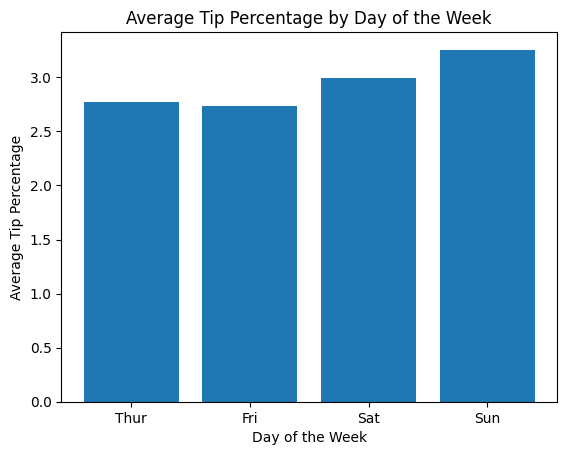

In [13]:
# Calculate average tip percentage by day
avg_tip_by_day = tips.groupby('day')['tip'].mean()
print(avg_tip_by_day)
avg_tip_by_day_percent = tips.groupby('day')['tip_percentage'].mean()
print(avg_tip_by_day_percent)
plt.bar(avg_tip_by_day.index, avg_tip_by_day.values)
plt.xlabel('Day of the Week')
plt.ylabel('Average Tip Percentage')
plt.title('Average Tip Percentage by Day of the Week')
plt.show()

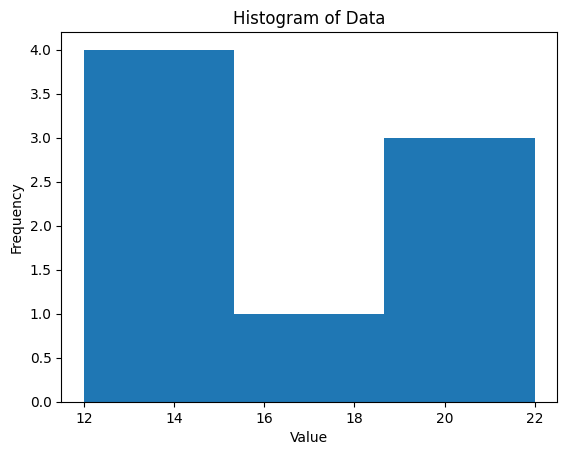

Mean: 16.625
Standard Deviation: 3.8709656418005056
Binned Statistics: BinnedStatisticResult(statistic=array([13., 18., 21.]), bin_edges=array([12.        , 15.33333333, 18.66666667, 22.        ]), binnumber=array([1, 1, 1, 1, 2, 3, 3, 3]))


DescribeResult(nobs=8, minmax=(12, 22), mean=16.625, variance=17.125, skewness=0.06525681329773589, kurtosis=-1.6476734867850917)

In [23]:
from scipy import stats
import numpy as np
data = [12, 15, 13, 12, 18, 20, 22, 21]
mean = np.mean(data)
std_dev = np.std(data)
bin_width =3
num_bins = int((max(data) - min(data)) / bin_width)
plt.hist(data, bins=num_bins)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Data')
plt.show()
print("Mean:", mean)
print("Standard Deviation:", std_dev)
binned_statistics = stats.binned_statistic(data, data, statistic='mean', bins=num_bins)
print("Binned Statistics:", binned_statistics)
stats.describe(data)
